In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_valid = pd.read_csv("../data/processed/X_valid.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_valid = pd.read_csv("../data/processed/y_valid.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)
print("Testing:", X_test.shape)

Training: (198608, 30)
Validation: (42559, 30)
Testing: (42559, 30)


In [3]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nFraud percentage in training set:")
print(y_train.value_counts(normalize=True) * 100)

X_train: (198608, 30)
X_valid: (42559, 30)
X_test : (42559, 30)

Training class distribution:
Class
0    198277
1       331
Name: count, dtype: int64

Fraud percentage in training set:
Class
0    99.83334
1     0.16666
Name: proportion, dtype: float64


In [4]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [5]:
start_time = time.perf_counter()

log_model.fit(X_train, y_train)

end_time = time.perf_counter()

log_training_time = end_time - start_time

print("Logistic Regression training completed.")
print(f"Training Time: {log_training_time:.4f} seconds")

Logistic Regression training completed.
Training Time: 1.3907 seconds


In [6]:
start_time = time.perf_counter()

y_valid_pred = log_model.predict(X_valid)
y_valid_prob = log_model.predict_proba(X_valid)[:, 1]

end_time = time.perf_counter()

log_prediction_time = end_time - start_time

print(f"Total Validation Prediction Time: {log_prediction_time:.6f} seconds")
print(
    f"Average Prediction Latency: "
    f"{(log_prediction_time / len(X_valid)) * 1000:.6f} ms/transaction"
)

Total Validation Prediction Time: 0.030917 seconds
Average Prediction Latency: 0.000726 ms/transaction


In [7]:
log_accuracy = accuracy_score(y_valid, y_valid_pred)
log_precision = precision_score(y_valid, y_valid_pred, zero_division=0)
log_recall = recall_score(y_valid, y_valid_pred, zero_division=0)
log_f1 = f1_score(y_valid, y_valid_pred, zero_division=0)
log_auc = roc_auc_score(y_valid, y_valid_prob)

print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("=" * 45)
print(f"Accuracy  : {log_accuracy:.4f}")
print(f"Precision : {log_precision:.4f}")
print(f"Recall    : {log_recall:.4f}")
print(f"F1-Score  : {log_f1:.4f}")
print(f"ROC-AUC   : {log_auc:.4f}")

LOGISTIC REGRESSION - VALIDATION RESULTS
Accuracy  : 0.9721
Precision : 0.0508
Recall    : 0.8873
F1-Score  : 0.0960
ROC-AUC   : 0.9719


In [8]:
print(
    classification_report(
        y_valid,
        y_valid_pred,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     42488
       Fraud       0.05      0.89      0.10        71

    accuracy                           0.97     42559
   macro avg       0.53      0.93      0.54     42559
weighted avg       1.00      0.97      0.98     42559



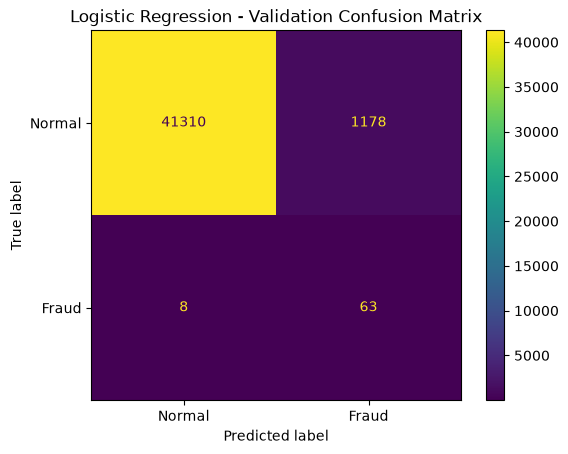

In [9]:
cm = confusion_matrix(y_valid, y_valid_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot(values_format="d")
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.show()

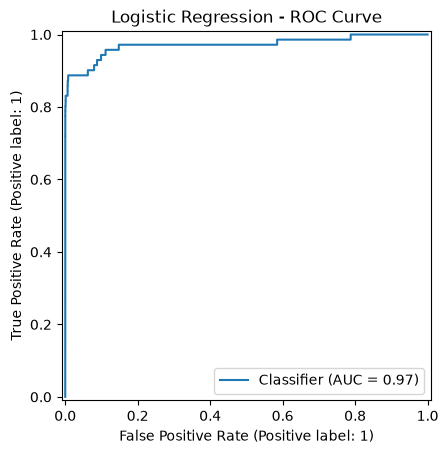

In [10]:
RocCurveDisplay.from_predictions(
    y_valid,
    y_valid_prob
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

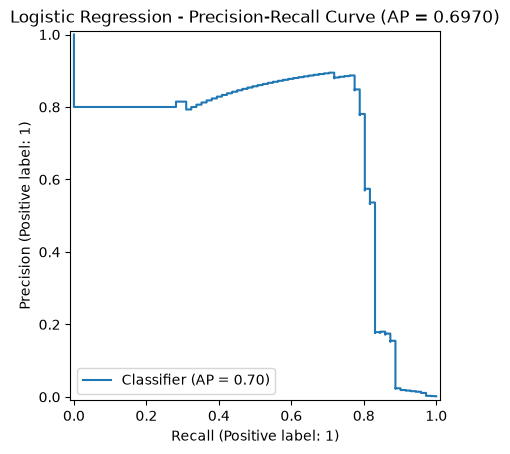

Average Precision (PR-AUC): 0.6970


In [11]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

log_pr_auc = average_precision_score(y_valid, y_valid_prob)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_valid_prob
)

plt.title(
    f"Logistic Regression - Precision-Recall Curve "
    f"(AP = {log_pr_auc:.4f})"
)

plt.show()

print(f"Average Precision (PR-AUC): {log_pr_auc:.4f}")